# EccoPy-2D-H — horizontal composites

`eccopy2d_h` classifies a **horizontal** field, shaped `(Y, X)`: a composite
reflectivity mosaic, a single CAPPI level, or any map-view grid.

```
reflectivity ──▶ texture ──▶ convectivity ──▶ 2-D clumping ──▶ echo type
               (2-D radial    (0–1 score)     (dual-threshold   (1 stratiform
                kernel)                        storm cells)      2 mixed
                                                                 3 convective)
```

Two things make this module different from the other three:

**Output is basic only** — codes 1, 2 and 3. There is no vertical axis, so
there is nothing to sub-classify into shallow/mid/deep. No `height`, `temp`
or `melt` inputs exist.

**The grid is usually not evenly spaced.** This notebook uses MRMS on a
0.01° latitude/longitude mesh, where east–west spacing shrinks toward the
pole. That makes it the natural place to look at `kernel_mode`, which is
inert on the evenly-spaced grids the other notebooks use.

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

from eccopy import eccopy2d_h, stats
from eccopy.params import WindowSpec, TextureParams, ClassificationParams
from eccopy.core.coords import latlon_to_xy_spacing
from eccopy.core.colormaps import (
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm, remap_echo_type, draw_window_ring,
)

plt.rcParams["figure.dpi"] = 110

## 1. The data

A 600 × 900 crop of the MRMS merged composite over the central Plains
(39–45 °N, 100–91 °W) during the 2021-12-15 serial derecho — a convective
line embedded in a broad stratiform shield, which is the case this
algorithm exists to separate.

MRMS marks missing data with two sentinels that are **not** declared as
`_FillValue`: −999 outside radar coverage, and −99 inside coverage with no
echo. `netCDF4`'s automatic masking does not catch either. The bundled file
has both converted to `NaN` already; if you read raw MRMS yourself, do that
conversion first or your texture field will be nonsense.

In [2]:
ds = nc.Dataset("data/mrms_composite_20211215.nc")

print(ds.title)
print(f"valid time  : {ds.valid_time}")
print(f"attribution : {ds.attribution}")
print()
for name, var in ds.variables.items():
    print(f"  {name:30s} {str(var.shape):14s} {var.units}")

MRMS composite reflectivity, 2021-12-15 22:38 UTC
valid time  : 2021-12-15T22:38:39Z
attribution : NOAA National Severe Storms Laboratory (public domain)

  latitude                       (600,)         degrees_north
  longitude                      (900,)         degrees_east
  MergedReflectivityQCComposite  (600, 900)     dBZ


In [3]:
lat = ds.variables["latitude"][:]     # (Y,) degrees north
lon = ds.variables["longitude"][:]    # (X,) degrees east
dbz = np.ma.filled(
    ds.variables["MergedReflectivityQCComposite"][:].astype(float), np.nan)

print(f"grid {dbz.shape}: {np.isfinite(dbz).mean():.1%} carries echo")
print(f"reflectivity {np.nanmin(dbz):.1f} to {np.nanmax(dbz):.1f} dBZ")
print(f"domain {lat.min():.2f}-{lat.max():.2f} N, {lon.min():.2f}-{lon.max():.2f} E")

grid (600, 900): 45.9% carries echo
reflectivity -3.5 to 62.0 dBZ
domain 39.01-45.00 N, -100.00--91.01 E


## 2. Turning latitude/longitude into spacing

EccoPy works in physical distance, not degrees. A 7 km texture window has
to cover a different number of grid cells at 45 °N than at 39 °N, because
0.01° of longitude is shorter nearer the pole.

`latlon_to_xy_spacing()` does the conversion. It takes **2-D** latitude and
longitude fields — one value per grid point — so build a meshgrid first.
Pass the result with `coord_mode="spacing"` to say "these are cell sizes,
not positions".

In [4]:
LAT, LON = np.meshgrid(lat, lon, indexing="ij")     # both (Y, X)
dy_km, dx_km = latlon_to_xy_spacing(LAT, LON)

print(f"dy: {dy_km.min():.3f} to {dy_km.max():.3f} km  (constant with latitude)")
print(f"dx: {dx_km.min():.3f} to {dx_km.max():.3f} km  "
      f"({100 * (dx_km.max() / dx_km.min() - 1):.1f}% variation across the domain)")
print(f"\na 7 km window spans {7 / dx_km.max():.1f} cells at the south edge "
      f"and {7 / dx_km.min():.1f} at the north edge")

dy: 1.112 to 1.112 km  (constant with latitude)
dx: 0.786 to 0.864 km  (9.9% variation across the domain)

a 7 km window spans 8.1 cells at the south edge and 8.9 at the north edge


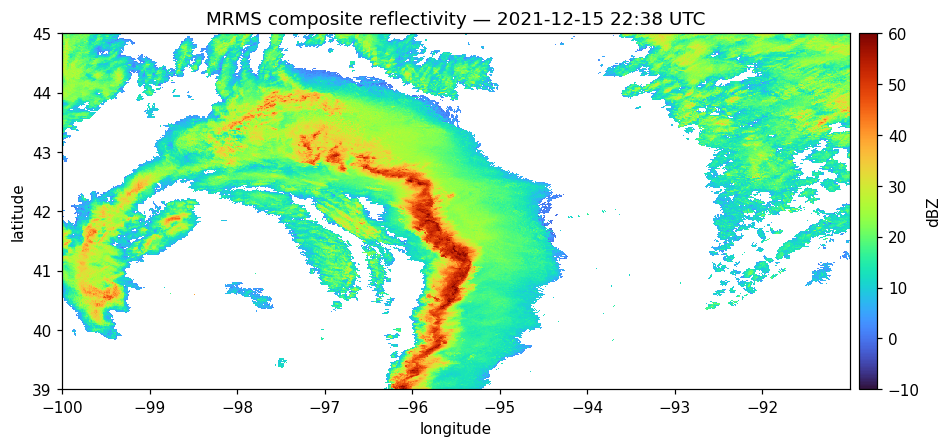

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
m = ax.pcolormesh(lon, lat, dbz, cmap="turbo", vmin=-10, vmax=60, shading="nearest")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("MRMS composite reflectivity — 2021-12-15 22:38 UTC")
fig.colorbar(m, ax=ax, label="dBZ", pad=0.01)
plt.show()

## 3. Parameters

Sensitivity tiers were measured on *this* scene; section 7 gives you the
tool to measure them on yours. Because 2-D-H has no vertical axis, it uses
a strict subset of the parameters the 3-D path consumes — anything about
heights, temperatures or clump depth simply does not apply.

### Texture — `TextureParams`

| Parameter | Direction | Mechanism | Sensitivity |
|---|---|---|---|
| `window` | larger → smoother texture, fewer cells | radius of the 2-D radial kernel | **high** |
| `texture_limit_high` | higher → lower convectivity | the normaliser: `convectivity = texture / texture_limit_high`, clipped to 1 | **high** |
| `dbz_base` | shifts the no-echo floor | subtracted before the variability statistic | **high** |
| `min_valid_dbz` | higher → weak echo dropped pre-texture | `None` resolves to 0.0 here, the ConvStratFinder default | **high** |
| `min_frac_texture` | higher → more points unclassified | kernel coverage needed to compute texture | **low** |
| `min_frac_fit` | higher → more points unclassified | kernel coverage needed to fit the local plane | **low** |

### Classification — `ClassificationParams` and `run()`

| Parameter | Direction | Mechanism | Sensitivity |
|---|---|---|---|
| `max_convectivity_for_stratiform` | higher → more stratiform | below this is stratiform; the gap to the next threshold is mixed | **high** |
| `min_convectivity_for_convective` | higher → less convective | seeds convective clumps | **moderate** |
| `use_dual_thresholds`, `secondary_convectivity` | control splitting of merged cells | an envelope is built at the primary threshold, then split using the secondary | **low** here |
| `all_subclumps_min_area_frac`, `each_subclump_min_area_frac`, `each_subclump_min_area_km2` | control whether a split is accepted | guard against fragmenting one cell into slivers | **low** here |
| `min_convective_area` *(a `run()` argument, not a params field)* | higher → small cells dropped | km² floor applied to finished clumps | **low** on the map, **high** on `n_clumps` |

**`each_subclump_min_area_km2` means a true area here.** In `eccopy3d` the
same field is a pseudo-*volume*. Sharing one `ClassificationParams`
instance between the two modules will not behave the way it reads.

**Judge the clump parameters by `n_clumps`, not by the map.** On this scene
`min_convective_area=100` changes 0.5 % of pixels while taking the clump
count from 78 to 11. That is the parameter working as intended: it removes
many tiny cells that occupy almost no area.

In [6]:
texture_params = TextureParams(
    dbz_base=0.0,             # reflectivity floor subtracted pre-texture
    texture_limit_high=30.0,  # convectivity normaliser
    min_valid_dbz=None,       # None -> 0.0 for this path (ConvStratFinder)
    min_frac_texture=0.25,    # kernel coverage needed to compute texture
    min_frac_fit=0.67,        # kernel coverage needed to fit the plane
)

class_params = ClassificationParams(
    max_convectivity_for_stratiform=0.4,   # below this -> stratiform
    min_convectivity_for_convective=0.5,   # at/above this -> convective
                                           # between the two -> mixed
    use_dual_thresholds=True,
    secondary_convectivity=0.65,
    all_subclumps_min_area_frac=0.33,
    each_subclump_min_area_frac=0.02,
    each_subclump_min_area_km2=2.0,        # a true AREA here; a pseudo-volume
                                           # in eccopy3d -- do not share one
                                           # ClassificationParams between them
)

# Height, temperature and melt have no meaning without a vertical axis, so
# eccopy2d_h.run() does not accept them and never emits sub-classified codes.

## 4. Running the classifier

`return_intermediates=True` adds `fitted_dbz` and `detrended_dbz`. Be aware
that for this module they come from a plain-Python double loop over every
grid point — on a 600 × 900 grid that is slow. It is off by default.

In [7]:
result = eccopy2d_h.run(
    dbz,
    coords_y=dy_km,
    coords_x=dx_km,
    coord_mode="spacing",      # dy_km/dx_km are cell sizes, not positions
    window=WindowSpec((7, "km")),
    kernel_mode="uniform",
    texture_params=texture_params,
    class_params=class_params,
    min_convective_area=None,  # km^2 floor on finished clumps; None = keep all
)

print(f"clumps found   : {result.n_clumps}")
print(f"texture radius : {result.texture_radius:.1f} km")
print(f"echo_type dtype: {result.echo_type.dtype}  "
      f"(float, NaN = no echo -- eccopy3d uses int16 with a 0 sentinel instead)")

clumps found   : 78
texture radius : 7.0 km
echo_type dtype: float64  (float, NaN = no echo -- eccopy3d uses int16 with a 0 sentinel instead)


## 5. Texture, convectivity and classification

`fraction_active` records how much of each kernel carried valid echo. It is
the field that decides where texture can be computed at all, so the ragged
outer boundary of the echo region shows up there first.

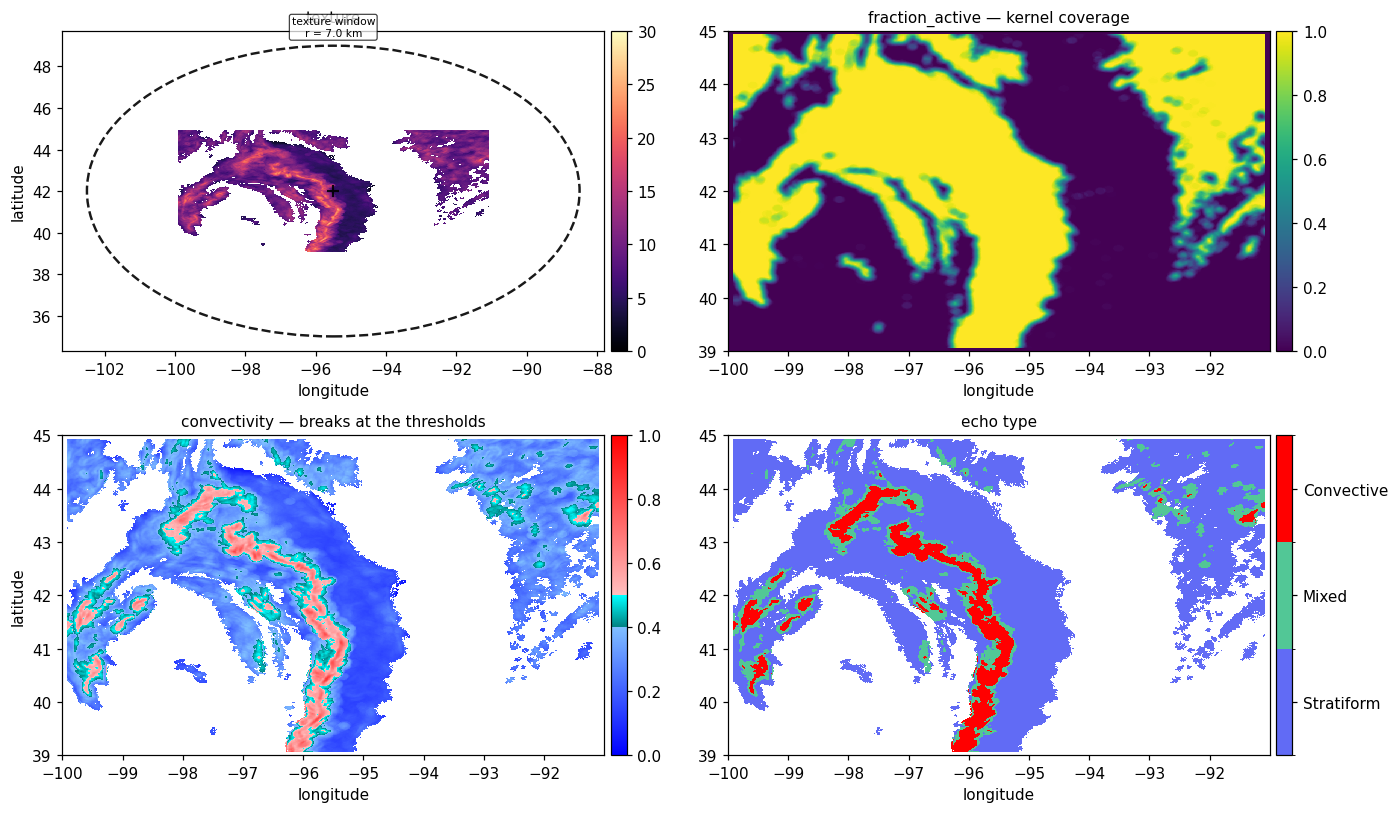

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

m = axes[0, 0].pcolormesh(lon, lat, result.texture, cmap="magma",
                          vmin=0, vmax=30, shading="nearest")
axes[0, 0].set_title("texture", fontsize=10)
fig.colorbar(m, ax=axes[0, 0], pad=0.01)
draw_window_ring(axes[0, 0], lon, lat, result.texture_radius)

m = axes[0, 1].pcolormesh(lon, lat, result.fraction_active, cmap="viridis",
                          vmin=0, vmax=1, shading="nearest")
axes[0, 1].set_title("fraction_active — kernel coverage", fontsize=10)
fig.colorbar(m, ax=axes[0, 1], pad=0.01)

m = axes[1, 0].pcolormesh(lon, lat, result.convectivity,
                          cmap=convectivity_cmap(
                              strat_mixed=class_params.max_convectivity_for_stratiform,
                              mixed_conv=class_params.min_convectivity_for_convective),
                          norm=convectivity_norm(), shading="nearest")
axes[1, 0].set_title("convectivity — breaks at the thresholds", fontsize=10)
fig.colorbar(m, ax=axes[1, 0], pad=0.01)

m = axes[1, 1].pcolormesh(lon, lat, remap_echo_type(result.echo_type),
                          cmap=basic_echo_type_cmap(), norm=basic_echo_type_norm(),
                          shading="nearest")
axes[1, 1].set_title("echo type", fontsize=10)
cb = fig.colorbar(m, ax=axes[1, 1], ticks=range(1, 4), pad=0.01)
cb.ax.set_yticklabels(BASIC_ECHO_TYPE_LABELS)

for ax in axes.ravel():
    ax.set_xlabel("longitude")
for ax in axes[:, 0]:
    ax.set_ylabel("latitude")
plt.tight_layout(); plt.show()

## 6. `kernel_mode` on a non-uniform grid

This is the one dataset in the notebook set where the choice matters.

- **`"uniform"`** resolves a single kernel from the median spacing across
  the whole domain, and applies it everywhere. This is what LROSE's
  `ConvStratFinder` itself does, even for lat/lon grids, and it is
  EccoPy's validated-fidelity default.
- **`"varying"`** resolves the kernel separately at every point from that
  point's local spacing. Physically the more defensible choice on a
  genuinely non-uniform grid — but it is *not* what the reference
  implementation does, so it has no ground truth behind it.

Neither is "the right answer". Treat any comparison between them as a
**sensitivity study**, not a measurement of accuracy.

In [9]:
varying = eccopy2d_h.run(
    dbz, coords_y=dy_km, coords_x=dx_km, coord_mode="spacing",
    window=WindowSpec((7, "km")), kernel_mode="varying",
    texture_params=texture_params, class_params=class_params,
)

both = np.isin(result.echo_type, [1, 2, 3]) | np.isin(varying.echo_type, [1, 2, 3])
print(f"overall disagreement: "
      f"{100 * (1 - (result.echo_type[both] == varying.echo_type[both]).mean()):.2f}%")
print(f"clumps: uniform {result.n_clumps}, varying {varying.n_clumps}")

print("\nby latitude band (dx shrinks toward the pole):")
for lo, hi in [(39, 40.5), (40.5, 42), (42, 43.5), (43.5, 45)]:
    band = (lat >= lo) & (lat < hi)
    u, v = result.echo_type[band], varying.echo_type[band]
    m = np.isin(u, [1, 2, 3]) | np.isin(v, [1, 2, 3])
    cu = 100 * np.isin(u, [3]).sum() / max(1, np.isin(u, [1, 2, 3]).sum())
    cv = 100 * np.isin(v, [3]).sum() / max(1, np.isin(v, [1, 2, 3]).sum())
    print(f"  {lo:4.1f}-{hi:4.1f} N   disagree {100 * (1 - (u[m] == v[m]).mean()):4.2f}%"
          f"   convective {cu:5.2f}% vs {cv:5.2f}%")

overall disagreement: 0.46%
clumps: uniform 78, varying 80

by latitude band (dx shrinks toward the pole):
  39.0-40.5 N   disagree 0.89%   convective 21.67% vs 21.20%
  40.5-42.0 N   disagree 0.90%   convective 13.48% vs 13.31%
  42.0-43.5 N   disagree 0.12%   convective  8.82% vs  8.83%
  43.5-45.0 N   disagree 0.37%   convective  3.36% vs  3.36%


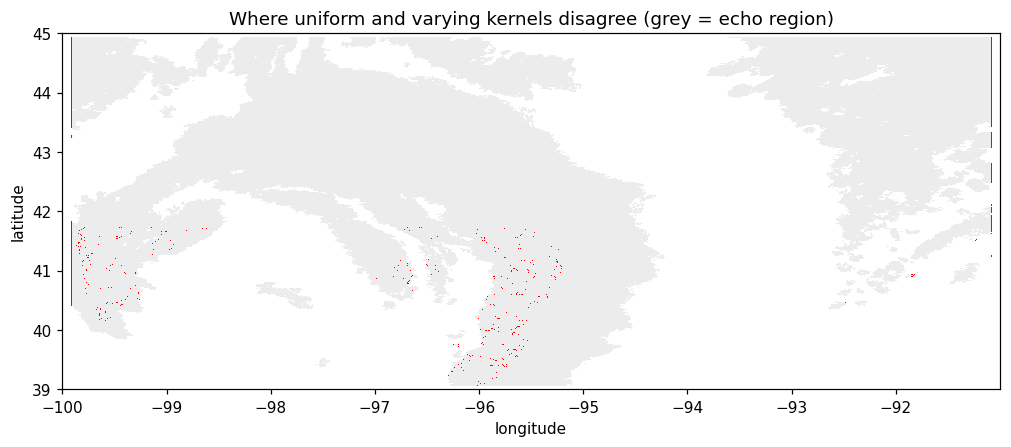

Disagreement clusters on class boundaries, not in cell interiors --
the two kernels differ by at most a cell or two of radius, so only
points already near a threshold can cross it.


In [10]:
diff = np.where(both, (result.echo_type != varying.echo_type).astype(float), np.nan)

fig, ax = plt.subplots(figsize=(11, 4.2))
m = ax.pcolormesh(lon, lat, np.ma.masked_where(diff != 1, diff),
                  cmap="autumn_r", vmin=0, vmax=1, shading="nearest")
ax.pcolormesh(lon, lat, np.where(np.isfinite(result.echo_type), 0.15, np.nan),
              cmap="Greys", vmin=0, vmax=1, shading="nearest", zorder=0)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Where uniform and varying kernels disagree (grey = echo region)")
plt.show()

print("Disagreement clusters on class boundaries, not in cell interiors --")
print("the two kernels differ by at most a cell or two of radius, so only")
print("points already near a threshold can cross it.")

### Inspecting the fit, on a crop

`return_intermediates=True` adds `fitted_dbz` and `detrended_dbz`, but for
this module they come from a plain-Python double loop over every grid
point. On the full 600 × 900 grid that is prohibitive; on a crop it is a
few seconds. Crop first, then inspect.

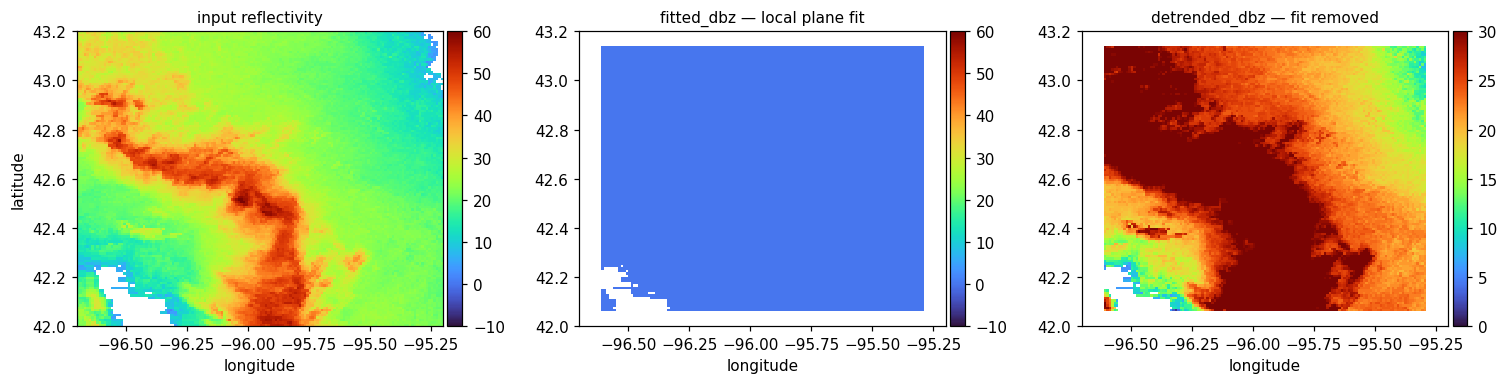

In [11]:
ys, xs = slice(180, 300), slice(330, 480)      # over the convective line
lat_c, lon_c, dbz_c = lat[ys], lon[xs], dbz[ys, xs]
LAT_c, LON_c = np.meshgrid(lat_c, lon_c, indexing="ij")
dy_c, dx_c = latlon_to_xy_spacing(LAT_c, LON_c)

crop = eccopy2d_h.run(
    dbz_c, coords_y=dy_c, coords_x=dx_c, coord_mode="spacing",
    window=WindowSpec((7, "km")), texture_params=texture_params,
    class_params=class_params, return_intermediates=True,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, field, title, kw in [
    (axes[0], dbz_c, "input reflectivity", dict(cmap="turbo", vmin=-10, vmax=60)),
    (axes[1], crop.fitted_dbz, "fitted_dbz — local plane fit",
     dict(cmap="turbo", vmin=-10, vmax=60)),
    (axes[2], crop.detrended_dbz, "detrended_dbz — fit removed",
     dict(cmap="turbo", vmin=0, vmax=30)),
]:
    m = ax.pcolormesh(lon_c, lat_c, field, shading="nearest", **kw)
    ax.set_title(title, fontsize=10); ax.set_xlabel("longitude")
    fig.colorbar(m, ax=ax, pad=0.01)
axes[0].set_ylabel("latitude")
plt.tight_layout(); plt.show()

## 7. Statistics

With no vertical axis, the height-aware functions in `eccopy.stats` do not
apply — `echo_top_height`, `echo_depth`, `convective_depth` and friends all
need a `height` argument this module cannot provide. What remains is
coverage fractions and clump geometry.

In [12]:
fractions = stats.echo_type_fractions(result.echo_type)
print(f"classified pixels : {fractions['n_valid']:,}")
for name in ("stratiform", "mixed", "convective"):
    print(f"  {name:12s} {fractions[name]:6.1%}")

classified pixels : 238,051
  stratiform    77.9%
  mixed         12.7%
  convective     9.4%


In [13]:
sizes = stats.clump_sizes(result.echo_type, category="convective")
print(f"convective regions in echo_type : {stats.n_clumps(result.echo_type, 'convective')}")
print(f"clumps found during clumping    : {result.n_clumps}")
print("  (different by design: one labels the FINAL echo_type field, the")
print("   other counts clumps found earlier on convectivity)")

if len(sizes):
    cell_km2 = float(np.nanmedian(dy_km) * np.nanmedian(dx_km))
    print(f"\nlargest region {int(sizes.max()):,} px "
          f"(~{sizes.max() * cell_km2:,.0f} km2)")
    print(f"median region  {int(np.median(sizes)):,} px")

convective regions in echo_type : 67
clumps found during clumping    : 78
  (different by design: one labels the FINAL echo_type field, the
   other counts clumps found earlier on convectivity)

largest region 14,111 px (~12,966 km2)
median region  15 px


## 8. Exploring parameters yourself

The tiers in section 3 came from this scene. Measure them on yours.

This reports `n_clumps` alongside the echo-type change, because the two
often disagree: clump-area parameters can leave the map nearly untouched
while changing the cell count several-fold.

In [14]:
from dataclasses import replace

BASE = dict(coords_y=dy_km, coords_x=dx_km, coord_mode="spacing",
            window=WindowSpec((7, "km")), texture_params=texture_params,
            class_params=class_params)


def sweep(values, make_kwargs, label=""):
    """Re-run across values, reporting echo-type change and clump count.

    make_kwargs(value) -> dict of run() overrides. Use dataclasses.replace()
    so only the swept field changes; rebuilding a params object by hand
    silently resets every field you omit.
    """
    reference = eccopy2d_h.run(dbz, **BASE)
    ref_mask = np.isin(reference.echo_type, [1, 2, 3])

    print(label)
    for value in values:
        r = eccopy2d_h.run(dbz, **{**BASE, **make_kwargs(value)})
        mask = ref_mask | np.isin(r.echo_type, [1, 2, 3])
        changed = 100 * (1 - (reference.echo_type[mask] == r.echo_type[mask]).mean())
        conv = stats.convective_percentage(r.echo_type)
        print(f"  {str(value):>8s}  {changed:5.1f}% changed"
              f"   convective {conv:5.1f}%   n_clumps {r.n_clumps:4d}")


sweep([3, 5, 7, 11], lambda v: dict(window=WindowSpec((v, "km"))),
      label="window radius (km)")

window radius (km)
         3   19.4% changed   convective   2.4%   n_clumps  235


         5   10.8% changed   convective   6.0%   n_clumps  161


         7    0.0% changed   convective   9.4%   n_clumps   78


        11   15.9% changed   convective  14.1%   n_clumps   54


In [15]:
sweep([0.30, 0.40, 0.50],
      lambda v: dict(class_params=replace(class_params,
                                          max_convectivity_for_stratiform=v)),
      label="max_convectivity_for_stratiform -- moves the strat/mixed boundary")

sweep([None, 4.0, 25.0, 100.0],
      lambda v: dict(min_convective_area=v),
      label="min_convective_area (km2) -- watch n_clumps, not the map")

max_convectivity_for_stratiform -- moves the strat/mixed boundary


       0.3   30.5% changed   convective   9.4%   n_clumps   78


       0.4    0.0% changed   convective   9.4%   n_clumps   78


       0.5   12.7% changed   convective   9.4%   n_clumps   78


min_convective_area (km2) -- watch n_clumps, not the map


      None    0.0% changed   convective   9.4%   n_clumps   78


       4.0    0.0% changed   convective   9.4%   n_clumps   50


      25.0    0.2% changed   convective   9.2%   n_clumps   23


     100.0    0.5% changed   convective   8.9%   n_clumps   11


## Where to go next

- `eccopy2d_v` — vertical cross-sections, sub-typed from the melting layer
- `eccopy3d` — full volumes, sub-typed from clump geometry
- `eccopy1d` — a single time series or transect

Algorithm sources and the full parameter reference are in the top-level
`README.md`. Contributions are welcome — see `CONTRIBUTING.md`, especially
the ground-truth standard for changes to the classification path.